<img src="https://raw.githubusercontent.com/drdave-teaching/OPIM5509-notebooks/main/_banners/opim5509_banner.svg" width="100%" alt="OPIM 5509 banner"/>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/drdave-teaching/OPIM5509-notebooks/blob/main/Module4/Univariate_Temperature_RNN_pt2.ipynb)

# Univariate Temperature RNN, Part 2: Reload, Explain, Roll Forward
--------------------------------------------------
**Dr. Dave Wanik - University of Connecticut**

Part 1 trained an LSTM on ten years of daily minimum temperatures and saved it. This notebook never trains anything. It **downloads that saved model**, rebuilds the test set, proves the reload, and then asks the two questions Part 1 left open:

1. **What is the model looking at?** - occlusion by lag and gradient saliency on a 10-day window
2. **What happens if you feed its own predictions back in?** - the autoregressive roll-forward, scored by horizon against the dumb baselines

🔴
<!-- 🎙 DAVE TALKING POINTS — M4 · 7-pt2 — Univariate RNN Pt 2b: reload the saved LSTM, explain it, roll it forward
- No training in this notebook - that's the point. Download the .keras file Part 1 saved, rebuild the SAME windows, prove the MAE matches (1.76). A model is an artifact you can hand to someone. Then the actual-vs-predicted pair: tight scatter, predictions tracking the test year - that's what 'good enough to reuse' looks like.
- Occlusion: blank one lag (replace it with the training mean) and re-score. Yesterday matters most; the effect fades over about a week. Gradient saliency says the same thing with calculus.
- Autoregressive roll-forward: predict tomorrow, append it, slide, predict the day after... The window fills with the model's own guesses. Show the year of launches: every red line is a 14-day forecast rolled forward from its dot. Within two or three days each one flattens out at a SEASONAL level (around 14 C in summer, 8 C in winter), not the overall mean - the 10-day window still carries the season even after the weather detail is gone.
- Actual vs predicted, three ways: day +1 hugs the red line; by day +3 and day +14 the cloud tips over. Read the slopes off the titles: 0.65 at day +1, 0.49 at day +3, 0.39 at day +14. A slope of 1 follows the weather, 0 predicts a flat line - watching it fall IS regression to the mean, and it's how you decide how far to trust a recursive forecast.
- Score it by horizon: day 1 1.78 C (= Part 1), then it settles at ~2.25 by day 3 and STAYS there through day 14 - still better than persistence (2.75) and climatology (3.2) because the window carries the season. Recursive doesn't blow up here: no covariates to fake, and a mean-reverting series. Contrast with demand in the energy notebooks, where it does.
-->


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from urllib.request import urlretrieve
from sklearn.metrics import mean_absolute_error, classification_report, confusion_matrix, f1_score
from keras.models import load_model
import keras
keras.utils.set_random_seed(5509)

## Rebuild the data exactly as Part 1 did

Same file, same `split_sequence`, same look-back of 10, same 90/10 chronological split. No scaling - Part 1 didn't scale either.

<!-- WINDOW-FN -->
## The window-making function: `split_sequence`

Chops **one column** into overlapping windows.

- **`n_steps`** is the **look-back**: each input X is `n_steps` values in a row.
- The target y is the **next** value after the window.

With `[10, 20, 30, 40, 50]` and `n_steps=3`: `[10, 20, 30] → 40`, then `[20, 30, 40] → 50`. The result is `(samples, n_steps)`, and we add a trailing `1` for Keras: `(samples, n_steps, 1)`.


In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/drdave-teaching/OPIM5509Files/main/OPIM5509_Module4_Files/data/daily-min-temperatures.csv")

def split_sequence(sequence, n_steps):
    X, y = [], []
    for i in range(len(sequence)):
        end_ix = i + n_steps
        if end_ix > len(sequence) - 1: break
        X.append(sequence[i:end_ix]); y.append(sequence[end_ix])
    return np.array(X), np.array(y)

n_steps = 10
X, y = split_sequence(df["Temp"].values, n_steps)
X = X.reshape(X.shape[0], n_steps, 1)
cut = int(0.9 * len(X))
X_train, X_test, y_train, y_test = X[:cut], X[cut:], y[:cut], y[cut:]
print("test windows:", X_test.shape, "| the model never saw these", len(y_test), "days")

test windows: (364, 10, 1) | the model never saw these 364 days


## Download the saved model and prove it's the same one

In [3]:
urlretrieve("https://raw.githubusercontent.com/drdave-teaching/OPIM5509Files/main/OPIM5509_Module4_Files/models/Univariate_Temperature_RNN.keras", "Univariate_Temperature_RNN.keras")      # the file the previous notebook saved - now a course asset
model = load_model("Univariate_Temperature_RNN.keras")
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30)             │         3,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,615 (45.38 KB)

 Trainable params: 3,871 (15.12 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 7,744 (30.25 KB)

In [4]:
pred = model.predict(X_test, verbose=0).ravel()
base_mae = mean_absolute_error(y_test, pred)
print(f"reloaded LSTM test MAE: {base_mae:.2f} C   (Part 1 reported 1.76)")
print(f"persistence (yesterday): {mean_absolute_error(y_test, X_test[:, -1, 0]):.2f} C | climatology (train mean): {mean_absolute_error(y_test, np.full(len(y_test), y_train.mean())):.2f} C")

reloaded LSTM test MAE: 1.76 C   (Part 1 reported 1.76)
persistence (yesterday): 2.02 C | climatology (train mean): 3.23 C


## How good is the reloaded model? Actual vs predicted

Before we explain a model, decide whether it deserves explaining. Left: every test day, actual against predicted (the red line is perfect). Right: the whole test year, so you can see where it tracks and where it lags.

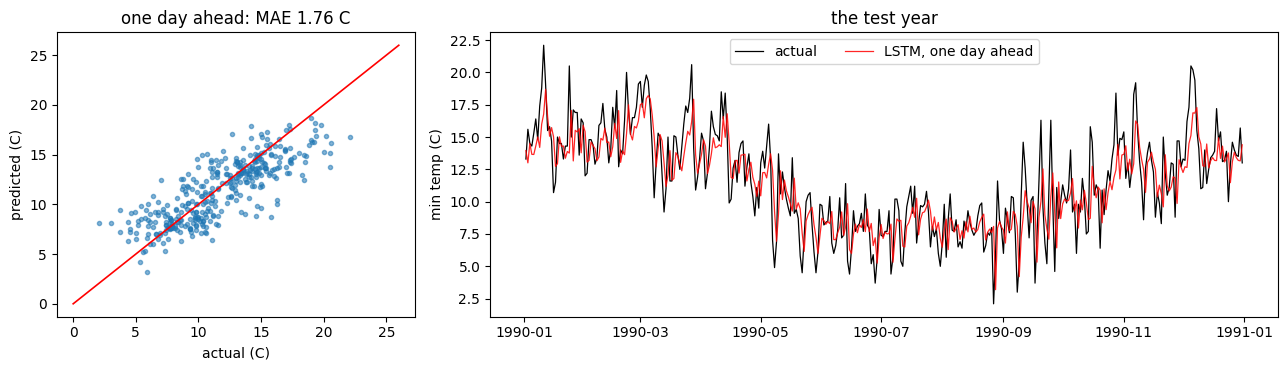

In [5]:
dates = pd.to_datetime(df["Date"])
test_dates = dates.iloc[n_steps + cut : n_steps + cut + len(y_test)]

fig, ax = plt.subplots(1, 2, figsize=(13, 3.8), gridspec_kw={"width_ratios": [1, 2.2]})
ax[0].scatter(y_test, pred, s=9, alpha=0.55)
ax[0].plot([0, 26], [0, 26], color="red", lw=1.2)
ax[0].set_xlabel("actual (C)"); ax[0].set_ylabel("predicted (C)")
ax[0].set_title(f"one day ahead: MAE {base_mae:.2f} C")
ax[1].plot(test_dates, y_test, color="black", lw=0.9, label="actual")
ax[1].plot(test_dates, pred, color="red", lw=0.9, alpha=0.85, label="LSTM, one day ahead")
ax[1].set_ylabel("min temp (C)"); ax[1].set_title("the test year"); ax[1].legend(loc="upper center", ncol=2)
plt.tight_layout(); plt.show()

## 1. Occlusion by lag

**The idea:** hide one day of the window and see how much the forecast moves. If the prediction barely changes, the model wasn't using that day.

### ✏️ A worked example: one real window

The forecast for **February 16, 1990** used these 10 days (°C, oldest first):

| day | -10 | -9 | -8 | -7 | -6 | -5 | -4 | -3 | -2 | -1 |
| :-- | --: | --: | --: | --: | --: | --: | --: | --: | --: | --: |
| temp | 12.9 | 13.4 | 15.9 | 16.1 | 17.6 | 15.6 | 15.0 | 13.0 | 14.1 | **17.3** |

The saved LSTM predicts **16.06 °C** (actual: 15.7). Now "blank" one day at a time by replacing it with the training average, **11.1 °C**, and predict again:

| day blanked | its value | becomes | new forecast | change |
| :-- | --: | --: | --: | --: |
| day -1 (yesterday) | 17.3 | 11.1 | 12.34 | **−3.72** |
| day -2 | 14.1 | 11.1 | 16.23 | +0.17 |
| day -3 | 13.0 | 11.1 | 15.80 | −0.26 |
| day -10 | 12.9 | 11.1 | 15.98 | −0.08 |

$$
\text{occlusion effect of day } k \;=\; \hat{y}\big(\text{window with day } k \text{ blanked}\big) \;-\; \hat{y}\big(\text{original window}\big)
$$

Blanking **yesterday** knocks almost 4 °C off the forecast; blanking any other day moves it by a few tenths. For this window, the model is mostly "yesterday, plus a small correction."

### From one window to all of them

One window is an anecdote. The code below blanks each day in **all 364 test windows** at once and reports how much the **test MAE** rises. That's the same idea, averaged: a big bar means the model can't do without that day.


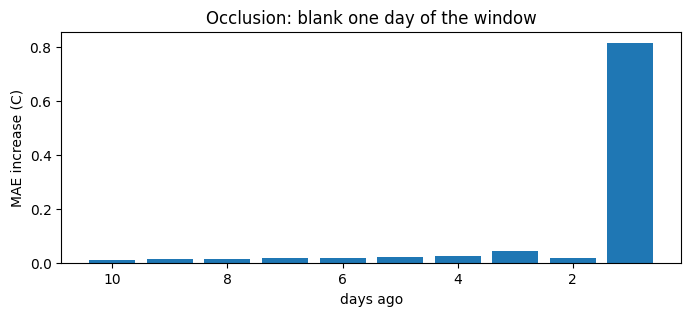

In [6]:
occ = []
for t in range(n_steps):
    Xo = X_test.copy(); Xo[:, t, 0] = y_train.mean()
    occ.append(mean_absolute_error(y_test, model.predict(Xo, verbose=0).ravel()) - base_mae)
days_ago = np.arange(n_steps, 0, -1)
plt.figure(figsize=(8, 3)); plt.bar(days_ago, occ); plt.gca().invert_xaxis()
plt.xlabel("days ago"); plt.ylabel("MAE increase (C)"); plt.title("Occlusion: blank one day of the window"); plt.show()

## 2. Gradient saliency

**The idea:** instead of hiding a day, *nudge* it. If yesterday were 1 °C warmer, how much would the forecast change? That rate is the gradient, and TensorFlow computes it for all 10 days in one pass.

$$
\text{saliency of day } k \;=\; \frac{\partial \hat{y}}{\partial x_k} \;\approx\; \frac{\text{change in forecast}}{\text{+1 °C on day } k}
$$

### ✏️ The same window, with gradients

| day | -10 | ... | -3 | -2 | -1 |
| :-- | --: | :-: | --: | --: | --: |
| gradient $\partial \hat{y} / \partial x_k$ | 0.043 | ... | 0.073 | −0.059 | **0.614** |

Read the last column as: **one extra degree yesterday adds about 0.61 °C to tomorrow's forecast.** Every other day adds less than a tenth of a degree.

**The two methods agree.** Occlusion lowered yesterday from 17.3 to 11.1, a change of −6.2 °C. The gradient predicts

$$
\Delta \hat{y} \;\approx\; \frac{\partial \hat{y}}{\partial x_{-1}} \times \Delta x_{-1} \;=\; 0.614 \times (-6.2) \;\approx\; -3.8 \text{ °C}
$$

and occlusion measured **−3.72 °C**. Close, because the model is nearly linear in yesterday's value over that range. When the two disagree, the model is doing something non-linear, and occlusion (the real experiment) is the one to trust.

### Three questions, three cells

A gradient is a **promise** the model makes about a nudge it has never actually seen, so we are going to make it
keep that promise before we believe any of it:

1. **One window.** The ten days above, with the signed gradient under each one - so you can see *where* the model is
   sensitive and in *which direction*.
2. **Does the promise hold?** We add a real +1 °C to one day on every test window and measure what the forecast
   actually did. If saliency is honest, measured and predicted land on the 45° line.
3. **All 364 windows.** One window could be a fluke. The heatmap shows whether "yesterday dominates" is the rule or
   just the average.


### A. One window, with the sign kept

The same February 1990 window as the worked example. Top: the ten days the model actually read. Bottom: the gradient
for each day - **green pushes the forecast up, red pushes it down**. Most of the bar chart is flat, and one bar isn't.

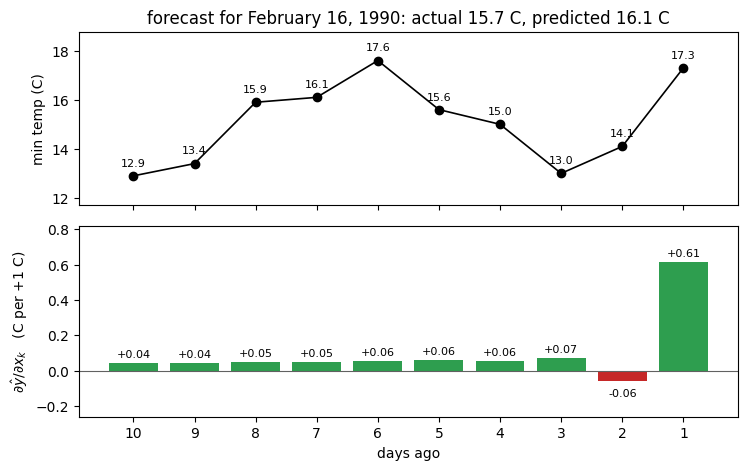

yesterday's gradient: +0.614 C per +1 C
the other nine days COMBINED: 0.489 C per +1 C (absolute values)
-> yesterday alone outweighs the other nine days put together


In [7]:
def saliency(model, X):
    x = tf.convert_to_tensor(X, dtype=tf.float32)
    with tf.GradientTape() as tape:
        tape.watch(x)
        out = model(x, training=False)
    return tape.gradient(out, x).numpy()

k = int(np.where(test_dates.dt.strftime("%Y-%m-%d") == "1990-02-16")[0][0])   # find it by date, don't hard-code it
g_one = saliency(model, X_test[k:k+1])[0].ravel()      # SIGNED gradient, one number per day
w_one = X_test[k].ravel()

fig, ax = plt.subplots(2, 1, figsize=(8.5, 5), sharex=True,
                       gridspec_kw={"height_ratios": [1, 1.1], "hspace": 0.12})
ax[0].plot(days_ago, w_one, marker="o", color="black", lw=1.2)
for d, v in zip(days_ago, w_one):
    ax[0].annotate(f"{v:.1f}", (d, v), textcoords="offset points", xytext=(0, 7), ha="center", fontsize=8)
ax[0].set_ylabel("min temp (C)"); ax[0].margins(y=0.25)
ax[0].set_title(f"forecast for {test_dates.iloc[k]:%B %d, %Y}: "
                f"actual {y_test[k]:.1f} C, predicted {pred[k]:.1f} C")
ax[1].bar(days_ago, g_one, color=["#2E9E4F" if v >= 0 else "#C62828" for v in g_one])
ax[1].axhline(0, color="#616161", lw=0.8)
for d, v in zip(days_ago, g_one):
    ax[1].annotate(f"{v:+.2f}", (d, v), textcoords="offset points", xytext=(0, 4 if v >= 0 else -11),
                   ha="center", fontsize=8)
ax[1].invert_xaxis(); ax[1].set_xticks(days_ago); ax[1].margins(y=0.3)
ax[1].set_xlabel("days ago"); ax[1].set_ylabel(r"$\partial \hat{y} / \partial x_k$   (C per +1 C)")
plt.show()

print(f"yesterday's gradient: {g_one[-1]:+.3f} C per +1 C")
print(f"the other nine days COMBINED: {np.abs(g_one[:-1]).sum():.3f} C per +1 C (absolute values)")
print("-> yesterday alone outweighs the other nine days put together")

### B. Does the gradient keep its promise?

A gradient is a **prediction about an experiment we have not run**: *"add one degree to day $k$ and my forecast moves
by this much."* So run the experiment. For each day we add a real **+1 °C** to that day in **every** test window and
measure what the forecast actually did.

If the two columns match, the gradient is telling the truth and you can read the bar chart as degrees. Where they
don't match, the model is behaving non-linearly and the **measured** column is the one to trust - a gradient is only
a local approximation.

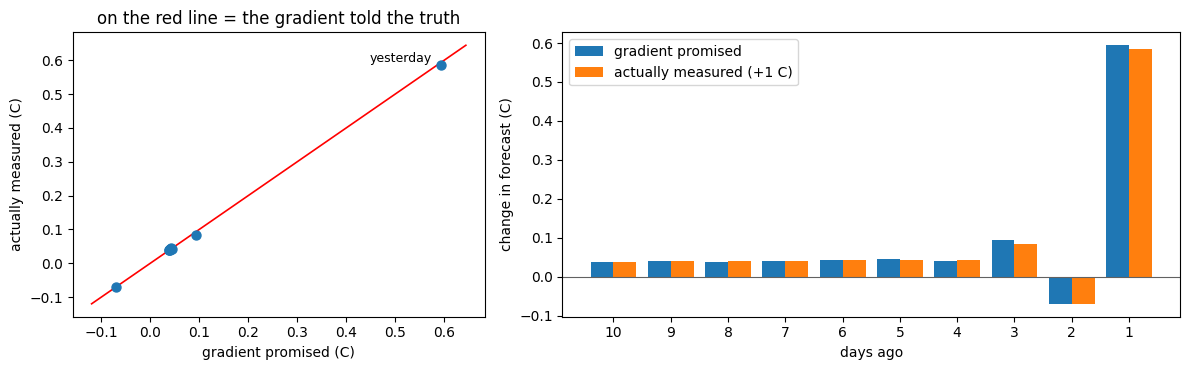

largest disagreement between promise and reality: 0.0105 C


,gradient promised,actually measured,gap
days ago,,,
10,0.038,0.038,0.000
9,0.040,0.041,0.001
8,0.038,0.039,0.002
7,0.040,0.041,0.001
6,0.043,0.044,0.001
5,0.045,0.043,-0.002
4,0.041,0.042,0.001
3,0.093,0.083,-0.010
2,-0.070,-0.070,-0.000


In [8]:
G = saliency(model, X_test)[:, :, 0]         # (windows, 10) signed gradients, every test window

rows = []
for t in range(n_steps):
    Xb = X_test.copy(); Xb[:, t, 0] += 1.0                                  # a real +1 C on that day
    measured = (model.predict(Xb, verbose=0).ravel() - pred).mean()         # what the forecast actually did
    rows.append({"days ago": int(days_ago[t]), "gradient promised": G[:, t].mean(), "actually measured": measured})
promise = pd.DataFrame(rows).set_index("days ago")
promise["gap"] = promise["actually measured"] - promise["gradient promised"]

fig, ax = plt.subplots(1, 2, figsize=(12, 3.8), gridspec_kw={"width_ratios": [1, 1.5]})
lim = [promise.iloc[:, :2].values.min() - 0.05, promise.iloc[:, :2].values.max() + 0.05]
ax[0].plot(lim, lim, color="red", lw=1.2, zorder=1)
ax[0].scatter(promise["gradient promised"], promise["actually measured"], s=42, zorder=2)
ax[0].annotate("yesterday", (promise["gradient promised"].iloc[-1], promise["actually measured"].iloc[-1]),
               textcoords="offset points", xytext=(-52, 2), fontsize=9)
ax[0].set_xlabel("gradient promised (C)"); ax[0].set_ylabel("actually measured (C)")
ax[0].set_title("on the red line = the gradient told the truth")
w = 0.4
ax[1].bar(days_ago + w/2, promise["gradient promised"], w, label="gradient promised")
ax[1].bar(days_ago - w/2, promise["actually measured"], w, label="actually measured (+1 C)")
ax[1].axhline(0, color="#616161", lw=0.8); ax[1].invert_xaxis(); ax[1].set_xticks(days_ago)
ax[1].set_xlabel("days ago"); ax[1].set_ylabel("change in forecast (C)"); ax[1].legend()
plt.tight_layout(); plt.show()

print(f"largest disagreement between promise and reality: {promise['gap'].abs().max():.4f} C")
promise.round(3)

### C. All 364 windows at once

One window could be a fluke, and a single mean bar hides how much the windows disagree. Left: **every** test window
as a row, dark where the model was sensitive - you are looking for a bright stripe on the right edge. Right: the
mean **|gradient|** with the middle 50% of windows shaded behind it.

We take the **absolute** value here, because a day can push the forecast up in one window and down in another, and
both mean that the model is sensitive to this day.

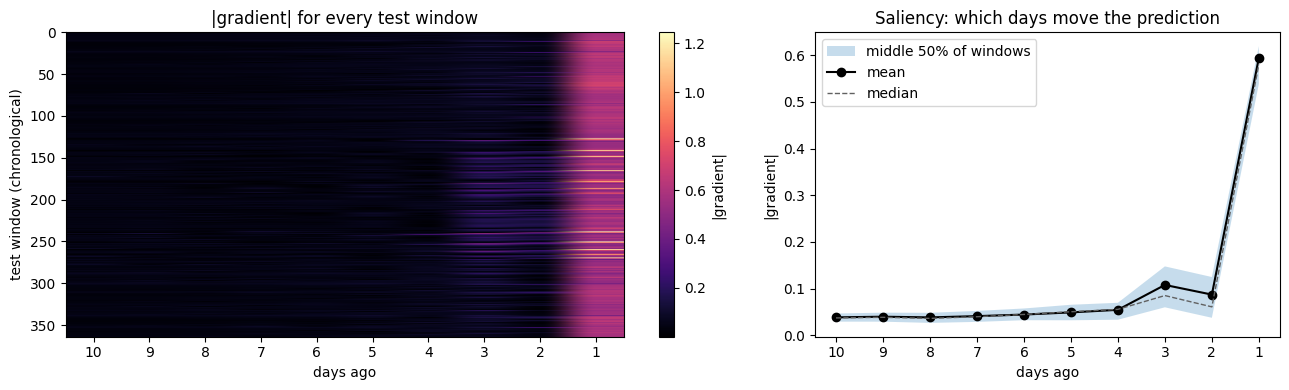

yesterday is the single most influential day in 100% of the 364 test windows
share of total |gradient| carried by yesterday: 54%


In [9]:
A = np.abs(G)                                           # (windows, 10)

fig, ax = plt.subplots(1, 2, figsize=(13, 4), gridspec_kw={"width_ratios": [1.5, 1]})
im = ax[0].imshow(A, aspect="auto", cmap="magma", extent=[10.5, 0.5, len(A), 0])
ax[0].set_xticks(days_ago); ax[0].set_xlabel("days ago"); ax[0].set_ylabel("test window (chronological)")
ax[0].set_title("|gradient| for every test window")
fig.colorbar(im, ax=ax[0], label="|gradient|")

lo, mid, hi = np.percentile(A, [25, 50, 75], axis=0)
ax[1].fill_between(days_ago, lo, hi, alpha=0.25, label="middle 50% of windows")
ax[1].plot(days_ago, A.mean(axis=0), marker="o", color="black", label="mean")
ax[1].plot(days_ago, mid, ls="--", lw=1, color="#616161", label="median")
ax[1].invert_xaxis(); ax[1].set_xticks(days_ago); ax[1].set_xlabel("days ago")
ax[1].set_ylabel("|gradient|"); ax[1].set_title("Saliency: which days move the prediction"); ax[1].legend()
plt.tight_layout(); plt.show()

wins = (A.argmax(axis=1) == n_steps - 1).mean()
print(f"yesterday is the single most influential day in {wins:.0%} of the {len(A)} test windows")
print(f"share of total |gradient| carried by yesterday: {A[:, -1].sum() / A.sum():.0%}")

**The two methods agree, and now you can say why.** Occlusion asked *"what breaks if this day goes
missing?"*; saliency asked *"what moves if this day changes a little?"* Both point at yesterday. Occlusion is the
real experiment and is always safe to trust; saliency is one cheap gradient pass instead of ten re-scorings, and
panel B is how you check that the shortcut was allowed to be taken.

## 3. Autoregressive roll-forward

The model predicts *one* day ahead from ten real days. To get a two-week forecast from it you have to **feed the prediction back in** as the newest day and slide the window - and after ten steps the window is entirely the model's own guesses. Roll forward from every test window and score each horizon.

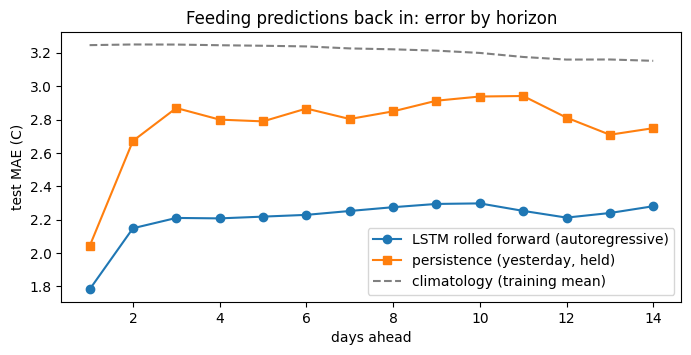

,autoregressive LSTM,persistence,climatology
day +1,1.78,2.04,3.25
day +2,2.15,2.67,3.25
day +3,2.21,2.87,3.25
day +7,2.25,2.80,3.23
day +14,2.28,2.75,3.15


In [10]:
def roll_forward(model, X0, horizon):
    window, preds = X0.copy(), []
    for h in range(horizon):
        p = model.predict(window, verbose=0)                              # (origins, 1)
        preds.append(p.ravel())
        window = np.concatenate([window[:, 1:, :], p[:, None, :]], axis=1)   # slide: drop the oldest day, append OUR prediction
    return np.array(preds).T                                              # (origins, horizon)

horizon = 14
temps = df["Temp"].values
origins = np.arange(cut, len(X) - horizon + 1)                              # every test window that has 14 real days after it
rec = roll_forward(model, X[origins], horizon)
truth = np.stack([temps[o + n_steps : o + n_steps + horizon] for o in origins])
mae_rec = np.abs(rec - truth).mean(axis=0)
mae_persist = np.array([mean_absolute_error(truth[:, h], X[origins][:, -1, 0]) for h in range(horizon)])   # "it stays like yesterday"
mae_clim = np.abs(truth - y_train.mean()).mean(axis=0)

plt.figure(figsize=(8, 3.5))
plt.plot(range(1, horizon+1), mae_rec, marker="o", label="LSTM rolled forward (autoregressive)")
plt.plot(range(1, horizon+1), mae_persist, marker="s", label="persistence (yesterday, held)")
plt.plot(range(1, horizon+1), mae_clim, "--", color="gray", label="climatology (training mean)")
plt.xlabel("days ahead"); plt.ylabel("test MAE (C)"); plt.title("Feeding predictions back in: error by horizon"); plt.legend(); plt.show()
pd.DataFrame({"autoregressive LSTM": mae_rec, "persistence": mae_persist, "climatology": mae_clim}, index=[f"day +{h}" for h in range(1, horizon+1)]).round(2).iloc[[0, 1, 2, 6, 13]]

### Every two weeks, a new 14-day forecast

One forecast tells you nothing. Here is the test year with a roll-forward launched every 14 days: each red line starts at the last real day the model saw (the dot) and runs 14 days on its own guesses.

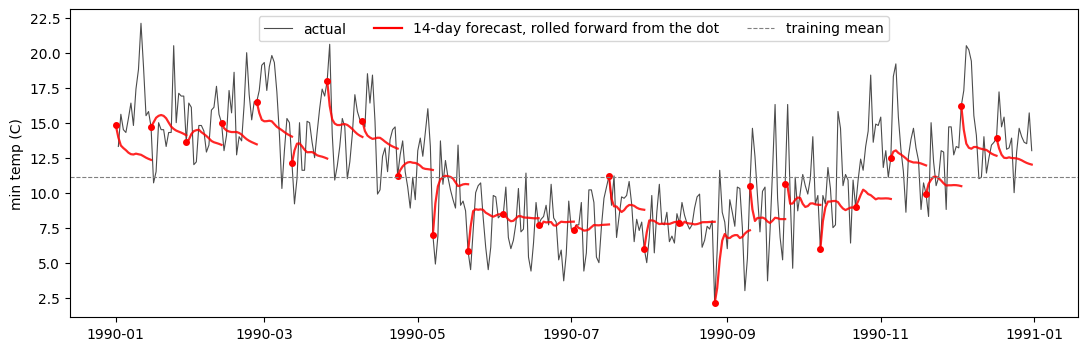

In [11]:
dates = pd.to_datetime(df["Date"])
fig, ax = plt.subplots(figsize=(13, 4))
t0 = origins[0] + n_steps
ax.plot(dates.iloc[t0 : t0 + len(origins) + horizon - 1], temps[t0 : t0 + len(origins) + horizon - 1],
        color="black", lw=0.8, alpha=0.7, label="actual")
for k in range(0, len(origins), 14):
    launch = origins[k] + n_steps - 1                                   # the last real day in the window
    xs = dates.iloc[launch : launch + horizon + 1]
    ys = np.r_[temps[launch], rec[k]]
    ax.plot(xs, ys, color="red", lw=1.6, alpha=0.85)
    ax.plot(xs.iloc[0], ys[0], "o", color="red", ms=4)
ax.plot([], [], color="red", lw=1.6, label="14-day forecast, rolled forward from the dot")
ax.axhline(y_train.mean(), color="gray", ls="--", lw=0.8, label="training mean")
ax.set_ylabel("min temp (C)"); ax.legend(loc="upper center", ncol=3); plt.show()

### Actual vs predicted at day +1, +3 and +14

The same scatter as before, now for rolled-forward forecasts. Watch the **fitted slope** in each title: 1 means the forecast still follows the weather, 0 means it has given up and predicts a flat line. Here it falls from 0.65 to 0.49 to 0.39. That drift is regression to the mean, and it's the picture that tells you how far to trust a recursive forecast.

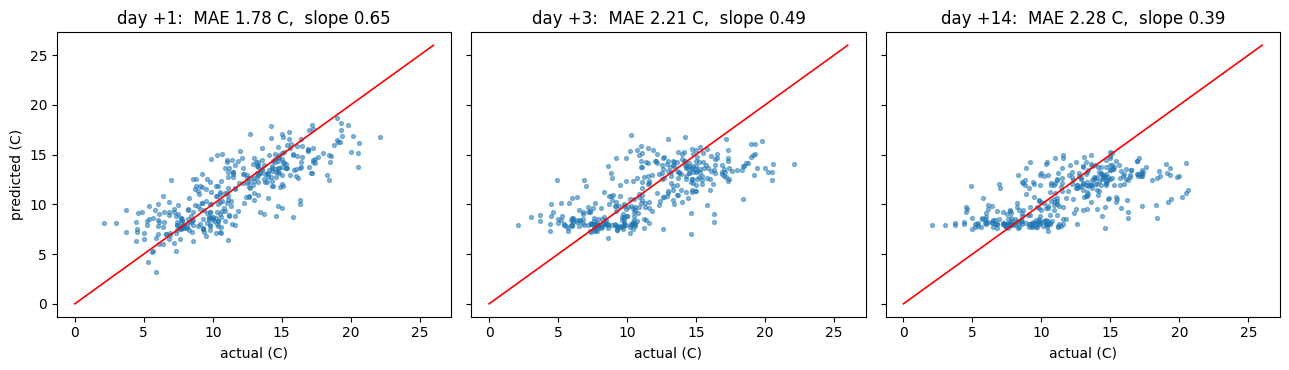

In [12]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.8), sharex=True, sharey=True)
for a, h in zip(ax, [1, 3, 14]):
    t, p = truth[:, h - 1], rec[:, h - 1]
    slope = np.polyfit(t, p, 1)[0]
    a.scatter(t, p, s=8, alpha=0.5)
    a.plot([0, 26], [0, 26], color="red", lw=1.2)
    a.set_title(f"day +{h}:  MAE {np.abs(t - p).mean():.2f} C,  slope {slope:.2f}")
    a.set_xlabel("actual (C)")
ax[0].set_ylabel("predicted (C)")
plt.tight_layout(); plt.show()

## What you just saw

- A **saved model is a reusable artifact**: same file, same predictions, on a different day, in a different notebook.
- The model leans on **yesterday** and the effect fades within the window - it learned persistence-plus-a-correction, which is what beat the baselines in Part 1.
- **Rolled forward, it regresses toward a seasonal level** - the scatter tips over (slope 0.65 at day +1, 0.39 at day +14) and every launch flattens within a few days. That's not a bug: with no future information the best guess *is* the climatology. Recursive forecasting is fine for a few steps; for a real multi-step forecast see the strategies notebook (direct and multi-output) in the energy section.

## On your own
- Roll forward from a *winter* origin and a *summer* origin. Which decays faster, and why?
- Replace the model with `Univariate_Temperature_Lags.keras` (the window-method dense net from the lags notebook - same 10-day inputs, shape `(samples, 10)`). Does a dense net roll forward any differently?